# # TEDS-D 2023 Data Processing Pipeline

###### This notebook processes raw TEDS-D 2023 data for machine learning and analysis.
###### 
###### **Objectives:**
###### - Load and explore raw TEDS-D 2023 data
###### - Handle missing values and data quality issues
###### - Engineer features for ML modeling
###### - Create analytical datasets for resource forecasting
###### - Save cleaned data for downstream applications


In [ ]:
# Import Libaries

import pandas as pd  # F401
import numpy as np  # F401
import matplotlib.pyplot as plt  # F401
import seaborn as sns  # F401
import os  # F401
from pathlib import Path  # F401
import warnings

warnings.filterwarnings("ignore")

# Set up visualization style
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

In [2]:
# Create directories if they don't exist
processed_dir = Path("../1_datasets/processed/")
processed_dir.mkdir(parents=True, exist_ok=True)

## 1. Load Raw Data

In [ ]:
# 1. Load Raw Data


def load_raw_data(file_path):
    """Load raw TEDS-D 2023 data with error handling"""
    try:
        df = pd.read_csv(file_path, low_memory=False)
        print(
            f"✅ Data loaded successfully: {df.shape[0]:,} rows, {df.shape[1]:,} columns"
        )
        return df
    except FileNotFoundError:
        print(f"❌ File not found: {file_path}")
        return None
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None

In [29]:
# Load the actual data
print("📁 Loading TEDS-D 2023 data...")
df_raw = pd.read_csv("../1_datasets/raw/tedsd_puf_2023.csv", low_memory=False)
print(f"✅ Data loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]:,} columns")

# Display column structure
print("\n📋 ACTUAL COLUMNS:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i:2d}. {col}")

📁 Loading TEDS-D 2023 data...
✅ Data loaded: 1,474,025 rows, 76 columns

📋 ACTUAL COLUMNS:
 1. DISYR
 2. CASEID
 3. STFIPS
 4. EDUC
 5. MARSTAT
 6. SERVICES
 7. DETCRIM
 8. LOS
 9. PSOURCE
10. NOPRIOR
11. ARRESTS
12. EMPLOY
13. METHUSE
14. PSYPROB
15. PREG
16. SEX
17. VET
18. LIVARAG
19. DAYWAIT
20. SERVICES_D
21. REASON
22. EMPLOY_D
23. LIVARAG_D
24. ARRESTS_D
25. DSMCRIT
26. AGE
27. RACE
28. ETHNIC
29. DETNLF
30. DETNLF_D
31. PRIMINC
32. SUB1
33. SUB2
34. SUB3
35. SUB1_D
36. SUB2_D
37. SUB3_D
38. ROUTE1
39. ROUTE2
40. ROUTE3
41. FREQ1
42. FREQ2
43. FREQ3
44. FREQ1_D
45. FREQ2_D
46. FREQ3_D
47. FRSTUSE1
48. FRSTUSE2
49. FRSTUSE3
50. HLTHINS
51. PRIMPAY
52. FREQ_ATND_SELF_HELP
53. FREQ_ATND_SELF_HELP_D
54. ALCFLG
55. COKEFLG
56. MARFLG
57. HERFLG
58. METHFLG
59. OPSYNFLG
60. PCPFLG
61. HALLFLG
62. MTHAMFLG
63. AMPHFLG
64. STIMFLG
65. BENZFLG
66. TRNQFLG
67. BARBFLG
68. SEDHPFLG
69. INHFLG
70. OTCFLG
71. OTHERFLG
72. DIVISION
73. REGION
74. IDU
75. ALCDRUG
76. CBSA2020


In [30]:
# Initial data exploration
print("\n🔍 DATA OVERVIEW:")
print(f"Dataset shape: {df_raw.shape}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n📊 DATA TYPES:")
print(df_raw.dtypes.value_counts())

print("\n👀 FIRST 3 ROWS:")
display(df_raw.head(3))


🔍 DATA OVERVIEW:
Dataset shape: (1474025, 76)
Memory usage: 854.69 MB

📊 DATA TYPES:
int64    76
Name: count, dtype: int64

👀 FIRST 3 ROWS:


,DISYR,CASEID,STFIPS,EDUC,MARSTAT,SERVICES,DETCRIM,LOS,PSOURCE,NOPRIOR,...,BARBFLG,SEDHPFLG,INHFLG,OTCFLG,OTHERFLG,DIVISION,REGION,IDU,ALCDRUG,CBSA2020
0,2023,1459504,2,3,4,7,-9,33,1,0,...,0,0,0,0,0,9,4,0,1,-9
1,2023,1366386,2,5,3,7,2,35,7,0,...,0,0,0,0,0,9,4,0,1,-9
2,2023,1343932,2,3,2,7,-9,37,3,0,...,0,0,0,0,1,9,4,0,3,-9


## 2. Data Quality Assessment

In [31]:
# Data Quality Assessment
def assess_data_quality(df):
    """Comprehensive data quality assessment"""
    print("🔍 DATA QUALITY ASSESSMENT")
    print("=" * 50)

    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

    print("📊 Missing Value Summary:")
    print(f"  Total columns: {len(df.columns)}")
    print(f"  Complete columns (0% missing): {len(missing_pct[missing_pct == 0])}")
    print(
        f"  Low missing (<5%): {len(missing_pct[(missing_pct > 0) & (missing_pct <= 5)])}"
    )
    print(
        f"  Medium missing (5-30%): {len(missing_pct[(missing_pct > 5) & (missing_pct <= 30)])}"
    )
    print(f"  High missing (>30%): {len(missing_pct[missing_pct > 30])}")

    if len(missing_pct[missing_pct > 30]) > 0:
        print(f"\n🚨 High missing columns (>30%):")
        for col, pct in missing_pct[missing_pct > 30].head(10).items():
            print(f"   {col}: {pct:.1f}%")

    return missing_pct


missing_pct = assess_data_quality(df_raw)

🔍 DATA QUALITY ASSESSMENT
📊 Missing Value Summary:
  Total columns: 76
  Complete columns (0% missing): 76
  Low missing (<5%): 0
  Medium missing (5-30%): 0
  High missing (>30%): 0


In [32]:
# Basic statistics for numerical columns
print("📊 NUMERICAL COLUMNS SUMMARY:")
df_raw.describe()

📊 NUMERICAL COLUMNS SUMMARY:


,DISYR,CASEID,STFIPS,EDUC,MARSTAT,SERVICES,DETCRIM,LOS,PSOURCE,NOPRIOR,...,BARBFLG,SEDHPFLG,INHFLG,OTCFLG,OTHERFLG,DIVISION,REGION,IDU,ALCDRUG,CBSA2020
count,1474025.0,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06,...,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06,1.474025e+06
mean,2023.0,8.083761e+05,2.521251e+01,9.237645e-01,-8.628626e-01,5.656903e+00,-7.253556e+00,1.932299e+01,1.614760e+00,-2.758230e-02,...,1.120741e-03,4.400875e-03,1.072573e-03,1.250996e-03,3.283526e-02,4.868097e+00,2.552634e+00,-1.082706e+00,1.800841e+00,2.101956e+04
std,0.0,4.946438e+05,1.480660e+01,4.623658e+00,4.620526e+00,1.863601e+00,4.396586e+00,1.462928e+01,4.488821e+00,2.441144e+00,...,3.345871e-02,6.619298e-02,3.273261e-02,3.534731e-02,1.782053e-01,2.539788e+00,1.128401e+00,3.193850e+00,9.521279e-01,1.712817e+04
min,2023.0,1.000000e+00,1.000000e+00,-9.000000e+00,-9.000000e+00,1.000000e+00,-9.000000e+00,1.000000e+00,-9.000000e+00,-9.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.000000e+00,0.000000e+00,-9.000000e+00
25%,2023.0,3.742630e+05,9.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,-9.000000e+00,3.000000e+00,1.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,-9.000000e+00
50%,2023.0,7.765220e+05,2.700000e+01,3.000000e+00,1.000000e+00,7.000000e+00,-9.000000e+00,2.300000e+01,1.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,3.000000e+00,0.000000e+00,2.000000e+00,2.252000e+04
75%,2023.0,1.254544e+06,3.700000e+01,3.000000e+00,1.000000e+00,7.000000e+00,-9.000000e+00,3.400000e+01,6.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,3.000000e+00,0.000000e+00,2.000000e+00,3.586000e+04
max,2023.0,1.676603e+06,7.200000e+01,5.000000e+00,4.000000e+00,8.000000e+00,8.000000e+00,3.700000e+01,7.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.000000e+00,4.000000e+00,1.000000e+00,3.000000e+00,4.974000e+04


# ## 3. Data Cleaning & Preprocessing

In [33]:
# Data Cleaning
def clean_teds_data(df):
    """Clean TEDS data with actual column names"""
    df_clean = df.copy()

    print("🧹 CLEANING DATA...")

    # Define cleaning strategies for each column type
    cleaning_strategy = {
        "demographic": [
            "AGE",
            "SEX",
            "RACE",
            "ETHNIC",
            "EDUC",
            "MARSTAT",
            "EMPLOY",
            "VET",
            "PREG",
        ],
        "substance": [
            "SUB1",
            "SUB2",
            "SUB3",
            "ROUTE1",
            "ROUTE2",
            "ROUTE3",
            "FREQ1",
            "FREQ2",
            "FREQ3",
            "FRSTUSE1",
            "FRSTUSE2",
            "FRSTUSE3",
        ],
        "treatment": ["SERVICES", "LOS", "PSOURCE", "NOPRIOR", "DAYWAIT", "REASON"],
        "clinical": [
            "PSYPROB",
            "ARRESTS",
            "LIVARAG",
            "HLTHINS",
            "PRIMPAY",
            "DSMCRIT",
            "IDU",
        ],
        "flags": [
            "ALCFLG",
            "COKEFLG",
            "MARFLG",
            "HERFLG",
            "METHFLG",
            "OPSYNFLG",
            "PCPFLG",
            "HALLFLG",
            "MTHAMFLG",
            "AMPHFLG",
            "STIMFLG",
            "BENZFLG",
            "TRNQFLG",
            "BARBFLG",
            "SEDHPFLG",
            "INHFLG",
            "OTCFLG",
            "OTHERFLG",
        ],
    }

    # Apply cleaning based on column type
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() == 0:
            continue

        missing_rate = df_clean[col].isnull().mean()

        # Substance columns - fill with 0 (no substance)
        if any(sub in col for sub in ["SUB", "ROUTE", "FREQ", "FRSTUSE"]):
            df_clean[col].fillna(0, inplace=True)

        # Flag columns (binary indicators) - fill with 0
        elif "FLG" in col:
            df_clean[col].fillna(0, inplace=True)

        # Demographic and categorical - fill with mode
        elif col in cleaning_strategy["demographic"]:
            mode_val = df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else -1
            df_clean[col].fillna(mode_val, inplace=True)

        # Treatment and clinical - fill with median for numeric, mode for categorical
        elif col in cleaning_strategy["treatment"] + cleaning_strategy["clinical"]:
            if df_clean[col].dtype in ["int64", "float64"]:
                df_clean[col].fillna(df_clean[col].median(), inplace=True)
            else:
                mode_val = (
                    df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else -1
                )
                df_clean[col].fillna(mode_val, inplace=True)

        # Default strategy
        else:
            if df_clean[col].dtype in ["int64", "float64"]:
                df_clean[col].fillna(df_clean[col].median(), inplace=True)
            else:
                mode_val = (
                    df_clean[col].mode()[0]
                    if len(df_clean[col].mode()) > 0
                    else "Unknown"
                )
                df_clean[col].fillna(mode_val, inplace=True)

    print(
        f"✅ Cleaning completed. Missing values: {df.isnull().sum().sum():,} → {df_clean.isnull().sum().sum():,}"
    )
    return df_clean


df_clean = clean_teds_data(df_raw)

🧹 CLEANING DATA...
✅ Cleaning completed. Missing values: 0 → 0


In [34]:
# Verify cleaning results
print("✅ CLEANING VERIFICATION:")
print(f"Original missing values: {df_raw.isnull().sum().sum():,}")
print(f"Cleaned missing values: {df_clean.isnull().sum().sum():,}")
print(f"Data types after cleaning:")
print(df_clean.dtypes.value_counts())

✅ CLEANING VERIFICATION:
Original missing values: 0
Cleaned missing values: 0
Data types after cleaning:
int64    76
Name: count, dtype: int64


## 4. Analyst the Data

In [ ]:
# Analyst the Actual Columns
def engineer_teds_features(df):
    """Engineer features using actual TEDS columns"""
    df_fe = df.copy()

    print("⚙️ ENGINEERING FEATURES...")

    # 1. Demographic Features
    print("👥 Creating demographic features...")

    # Age groups
    df_fe["age_group"] = pd.cut(
        df_fe["AGE"],
        bins=[0, 18, 25, 35, 45, 55, 65, 100],
        labels=["Under18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
    )

    # Gender mapping
    gender_map = {1: "Male", 2: "Female"}
    df_fe["sex"] = df_fe["SEX"].map(gender_map)

    # Race mapping
    race_map = {
        1: "White",
        2: "Black",
        3: "Native American",
        4: "Asian/Pacific Islander",
        5: "Other/Unknown",
    }
    df_fe["race"] = df_fe["RACE"].map(race_map)

    # Ethnicity mapping
    ethnic_map = {1: "Not Hispanic", 2: "Hispanic"}
    df_fe["ethnicity"] = df_fe["ETHNIC"].map(ethnic_map)

    # Education level
    educ_map = {
        1: "Less than 8th grade",
        2: "Some high school",
        3: "High school graduate",
        4: "Some college",
        5: "Associate degree",
        6: "Bachelor degree",
        7: "Graduate degree",
    }
    df_fe["education_level"] = df_fe["EDUC"].map(educ_map)

    # Employment status
    employ_map = {
        1: "Full-time",
        2: "Part-time",
        3: "Unemployed",
        4: "Not in labor force",
        5: "Student",
        6: "Retired",
        7: "Disabled",
        8: "Inmate",
    }
    df_fe["employment_status"] = df_fe["EMPLOY"].map(employ_map)

    # 2. Substance Use Features
    print("💊 Creating substance use features...")

    # Primary substance mapping
    substance_map = {
        1: "Alcohol",
        2: "Cocaine/Crack",
        3: "Marijuana/Hashish",
        4: "Heroin",
        5: "Non-Rx Methadone",
        6: "Other Opiates/Synthetics",
        7: "PCP",
        8: "Other Hallucinogens",
        9: "Methamphetamine/Speed",
        10: "Other Amphetamines",
        11: "Other Stimulants",
        12: "Benzodiazepines",
        13: "Other Tranquilizers",
        14: "Barbiturates",
        15: "Other Sedatives/Hypnotics",
        16: "Inhalants",
        17: "Over-the-Counter",
        18: "Other",
        19: "Unknown",
    }
    df_fe["primary_substance"] = df_fe["SUB1"].map(substance_map)
    df_fe["secondary_substance"] = df_fe["SUB2"].map(
        lambda x: substance_map.get(x, "None") if x != 0 else "None"
    )

    # Polysubstance use flag
    df_fe["is_polysubstance"] = (df_fe["SUB2"] > 0).astype(int)

    # Injection drug use
    df_fe["is_injection_user"] = (df_fe["IDU"] == 1).astype(int)

    # 3. Service Type Features
    print("🏥 Creating service type features...")

    service_map = {
        1: "Detox 24hr Residential",
        2: "Detox 24hr Hospital",
        3: "Rehab Residential",
        4: "Rehab Hospital",
        5: "Intensive Outpatient",
        6: "Non-intensive Outpatient",
    }
    df_fe["service_type"] = df_fe["SERVICES"].map(service_map)

    # 4. Clinical Complexity Features
    print("🏥 Creating clinical complexity features...")

    # Mental health disorder
    df_fe["has_mental_health_disorder"] = (df_fe["PSYPROB"] == 1).astype(int)

    # Homelessness (LIVARAG = 1 indicates homeless)
    df_fe["is_homeless"] = (df_fe["LIVARAG"] == 1).astype(int)

    # Veteran status
    df_fe["is_veteran"] = (df_fe["VET"] == 1).astype(int)

    # Criminal justice involvement
    df_fe["has_criminal_justice_involvement"] = (df_fe["DETCRIM"] == 1).astype(int)

    # 5. Complexity Score
    print("📊 Creating complexity score...")

    df_fe["complexity_score"] = (
        df_fe["is_polysubstance"] * 1.5
        + df_fe["has_mental_health_disorder"] * 1.8
        + df_fe["is_homeless"] * 1.5
        + df_fe["is_injection_user"] * 2.0
        + (df_fe["NOPRIOR"] > 3) * 1.2
        + (df_fe["ARRESTS"] > 0) * 0.8
        + (df_fe["has_criminal_justice_involvement"]) * 1.0
    )

    # 6. Treatment Outcome Features
    print("🎯 Creating treatment outcome features...")

    # Treatment completion
    reason_map = {
        1: "Completed",
        2: "Transferred",
        3: "Left Against Advice",
        4: "Terminated",
        5: "Other",
    }
    df_fe["discharge_reason"] = df_fe["REASON"].map(reason_map)
    df_fe["completed_treatment"] = (df_fe["REASON"] == 1).astype(int)

    # Length of stay categories
    df_fe["los_category"] = pd.cut(
        df_fe["LOS"],
        bins=[0, 7, 30, 90, 365, 10000],
        labels=["<1 week", "1-4 weeks", "1-3 months", "3-12 months", ">1 year"],
    )

    print(
        f"✅ Feature engineering completed. Added {len([col for col in df_fe.columns if col not in df.columns])} new features"
    )
    return df_fe


df_engineered = engineer_teds_features(df_clean)

⚙️ ENGINEERING FEATURES...
👥 Creating demographic features...
💊 Creating substance use features...
🏥 Creating service type features...
🏥 Creating clinical complexity features...
📊 Creating complexity score...
🎯 Creating treatment outcome features...
✅ Feature engineering completed. Added 19 new features


In [ ]:
# Display engineered features
print("🎯 ENGINEERED FEATURES SUMMARY:")
new_features = [col for col in df_engineered.columns if col not in df_raw.columns]

print(f"\n📋 New features created ({len(new_features)}):")
for feature in new_features:
    print(f"  - {feature}")

print("\n📊 SAMPLE DISTRIBUTIONS:")
sample_features = [
    "age_group",
    "sex",
    "race",
    "service_type",
    "primary_substance",
    "education_level",
]
for feature in sample_features:
    if feature in df_engineered.columns:
        print(f"\n{feature}:")
        print(df_engineered[feature].value_counts().head())

🎯 ENGINEERED FEATURES SUMMARY:

📋 New features created (19):
  - age_group
  - sex
  - race
  - ethnicity
  - education_level
  - employment_status
  - primary_substance
  - secondary_substance
  - is_polysubstance
  - is_injection_user
  - service_type
  - has_mental_health_disorder
  - is_homeless
  - is_veteran
  - has_criminal_justice_involvement
  - complexity_score
  - discharge_reason
  - completed_treatment
  - los_category

📊 SAMPLE DISTRIBUTIONS:

age_group:
age_group
Under18    1474025
18-24            0
25-34            0
35-44            0
45-54            0
Name: count, dtype: int64

sex:
sex
Male      966184
Female    506932
Name: count, dtype: int64

race:
race
Other/Unknown             931341
Asian/Pacific Islander    261906
Black                      59111
White                       2832
Native American              932
Name: count, dtype: int64

service_type:
service_type
Detox 24hr Hospital         182424
Rehab Hospital              166539
Non-intensive Outpatient 

## 5. ML-ready dataset

In [37]:
# Create ML-ready dataset
def create_ml_dataset(df):
    """Create machine learning ready dataset"""

    # Select features for ML
    ml_features = [
        # Engineered features
        "age_group",
        "sex",
        "race",
        "ethnicity",
        "education_level",
        "employment_status",
        "service_type",
        "primary_substance",
        "secondary_substance",
        "has_mental_health_disorder",
        "is_polysubstance",
        "is_injection_user",
        "is_homeless",
        "is_veteran",
        "has_criminal_justice_involvement",
        "complexity_score",
        "completed_treatment",
        "los_category",
        "discharge_reason",
        # Important original features
        "AGE",
        "LOS",
        "NOPRIOR",
        "ARRESTS",
        "DAYWAIT",
        "FRSTUSE1",
        "STFIPS",
        "REGION",
        "DIVISION",  # Geographic features
        # Substance flags for feature importance
        "ALCFLG",
        "COKEFLG",
        "MARFLG",
        "HERFLG",
        "METHFLG",
        "OPSYNFLG",
    ]

    # Only include features that exist
    existing_features = [f for f in ml_features if f in df.columns]
    df_ml = df[existing_features].copy()

    print(f"📊 Selected {len(existing_features)} features for ML dataset")

    # One-hot encode categorical variables
    categorical_cols = df_ml.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    print(f"🔧 One-hot encoding {len(categorical_cols)} categorical columns...")
    df_encoded = pd.get_dummies(
        df_ml, columns=categorical_cols, prefix=categorical_cols
    )

    print(
        f"✅ ML dataset created: {df_encoded.shape[0]:,} rows, {df_encoded.shape[1]:,} columns"
    )
    return df_encoded


df_ml_ready = create_ml_dataset(df_engineered)

📊 Selected 34 features for ML dataset
🔧 One-hot encoding 11 categorical columns...
✅ ML dataset created: 1,474,025 rows, 103 columns


## 6. Data Validation & Quality Checks

In [42]:
# Data Validation
def validate_processed_data(df):
    """Validate the processed data"""
    print("🔍 VALIDATING PROCESSED DATA...")

    # Check for missing values
    missing_total = df.isnull().sum().sum()
    print(f"✅ Missing values: {missing_total}")

    # Check data types
    numeric_cols = len(df.select_dtypes(include=[np.number]).columns)
    categorical_cols = len(df.select_dtypes(include=["object", "category"]).columns)
    print(f"✅ Numeric columns: {numeric_cols}")
    print(f"✅ Categorical columns: {categorical_cols}")

    # Check key ranges
    if "complexity_score" in df.columns:
        print(
            f"✅ Complexity score range: {df['complexity_score'].min():.2f} to {df['complexity_score'].max():.2f}"
        )

    if "AGE" in df.columns:
        print(f"✅ Age range: {df['AGE'].min()} to {df['AGE'].max()}")

    if "LOS" in df.columns:
        print(f"✅ Length of stay range: {df['LOS'].min()} to {df['LOS'].max()} days")

    return missing_total == 0


validation_passed = validate_processed_data(df_ml_ready)

🔍 VALIDATING PROCESSED DATA...
✅ Missing values: 0
✅ Numeric columns: 23
✅ Categorical columns: 0
✅ Complexity score range: 0.00 to 8.60
✅ Age range: 1 to 12
✅ Length of stay range: 1 to 37 days


## 7. Save Processed Data

In [43]:
# Save Processed Data
def save_processed_data(df, filename):
    """Save processed data to specified location"""
    try:
        filepath = processed_dir / filename

        # Save main dataset
        df.to_csv(filepath, index=False)
        print(f"✅ Main data saved: {filepath}")
        print(f"📁 File size: {os.path.getsize(filepath) / 1024**2:.2f} MB")

        # Save sample for testing
        sample_path = processed_dir / "tedsd_sample_clean.csv"
        sample_size = min(10000, len(df))
        df.sample(sample_size).to_csv(sample_path, index=False)
        print(f"✅ Sample data saved ({sample_size} rows): {sample_path}")

        # Save engineered features only (for analysis)
        engineered_cols = [
            col
            for col in df.columns
            if any(x in col for x in ["_", "group", "level", "category", "is_", "has_"])
        ]
        if engineered_cols:
            engineered_df = df[engineered_cols]
            engineered_path = processed_dir / "tedsd_engineered_features.csv"
            engineered_df.to_csv(engineered_path, index=False)
            print(f"✅ Engineered features saved: {engineered_path}")

        return True

    except Exception as e:
        print(f"❌ Error saving data: {e}")
        return False


# Save all datasets
save_success = save_processed_data(df_ml_ready, "tedsd_ml_clean.csv")

✅ Main data saved: ..\1_datasets\processed\tedsd_ml_clean.csv
📁 File size: 734.63 MB
✅ Sample data saved (10000 rows): ..\1_datasets\processed\tedsd_sample_clean.csv
✅ Engineered features saved: ..\1_datasets\processed\tedsd_engineered_features.csv


## 8. Summary Report

In [44]:
# Final Summary Report
def generate_summary_report(df_raw, df_processed, df_engineered):
    """Generate comprehensive summary report"""
    print("\n" + "=" * 60)
    print("📊 DATA PROCESSING SUMMARY REPORT")
    print("=" * 60)

    print(f"📈 DATA VOLUME:")
    print(f"   Raw data:        {df_raw.shape[0]:,} rows, {df_raw.shape[1]:,} columns")
    print(
        f"   Engineered data: {df_engineered.shape[0]:,} rows, {df_engineered.shape[1]:,} columns"
    )
    print(
        f"   ML-ready data:   {df_processed.shape[0]:,} rows, {df_processed.shape[1]:,} columns"
    )

    print(f"\n🎯 FEATURE ENGINEERING:")
    new_features = [col for col in df_engineered.columns if col not in df_raw.columns]
    print(f"   New features created: {len(new_features)}")
    print(
        f"   Key features: age_group, sex, race, service_type, primary_substance, complexity_score, etc."
    )

    print(f"\n🧹 DATA QUALITY:")
    original_missing = df_raw.isnull().sum().sum()
    processed_missing = df_processed.isnull().sum().sum()
    print(f"   Missing values reduced: {original_missing:,} → {processed_missing:,}")

    print(f"\n📁 OUTPUT FILES:")
    print(f"   1. tedsd_ml_clean.csv - Full ML-ready dataset")
    print(f"   2. tedsd_sample_clean.csv - Sample for testing")
    print(f"   3. tedsd_engineered_features.csv - Engineered features only")

    print(f"\n🚀 READY FOR:")
    print(f"   • Machine Learning Models")
    print(f"   • Streamlit Dashboard")
    print(f"   • Resource Forecasting")
    print(f"   • Clinical Analytics")

    print("=" * 60)


generate_summary_report(df_raw, df_ml_ready, df_engineered)


📊 DATA PROCESSING SUMMARY REPORT
📈 DATA VOLUME:
   Raw data:        1,474,025 rows, 76 columns
   Engineered data: 1,474,025 rows, 95 columns
   ML-ready data:   1,474,025 rows, 103 columns

🎯 FEATURE ENGINEERING:
   New features created: 19
   Key features: age_group, sex, race, service_type, primary_substance, complexity_score, etc.

🧹 DATA QUALITY:
   Missing values reduced: 0 → 0

📁 OUTPUT FILES:
   1. tedsd_ml_clean.csv - Full ML-ready dataset
   2. tedsd_sample_clean.csv - Sample for testing
   3. tedsd_engineered_features.csv - Engineered features only

🚀 READY FOR:
   • Machine Learning Models
   • Streamlit Dashboard
   • Resource Forecasting
   • Clinical Analytics


## 9. Quick Visualization


📈 CREATING FINAL VISUALIZATIONS...


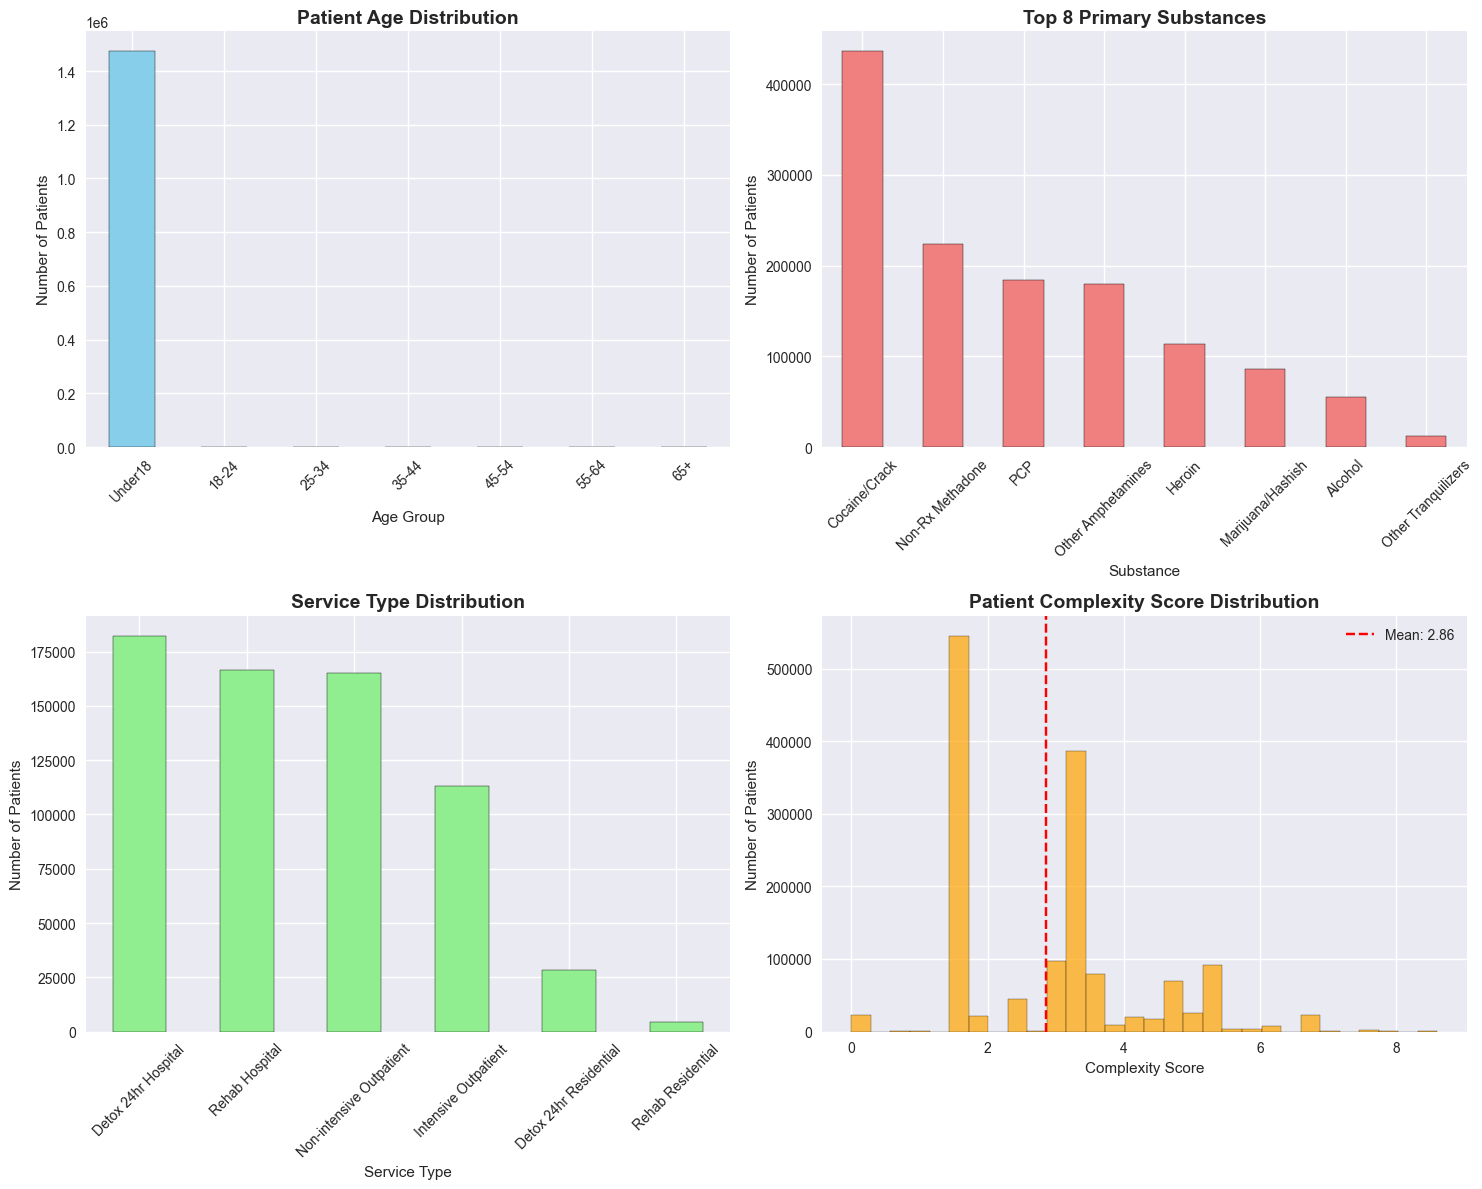


📊 COMPLEXITY SCORE STATISTICS:
   Mean: 2.86
   Std:  1.41
   Min:  0.00
   Max:  8.60
   High complexity (>5): 9.1%

🎉 PROCESSING COMPLETED! Your data is ready for analysis and modeling.
📁 Check the '1_datasets/processed/' folder for output files.


In [45]:
# Quick Visualizations
def create_final_visualizations(df):
    """Create final visualizations of key features"""
    print("\n📈 CREATING FINAL VISUALIZATIONS...")

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Age distribution
    if "age_group" in df.columns:
        df["age_group"].value_counts().sort_index().plot(
            kind="bar", ax=axes[0, 0], color="skyblue", edgecolor="black"
        )
        axes[0, 0].set_title("Patient Age Distribution", fontsize=14, fontweight="bold")
        axes[0, 0].set_xlabel("Age Group")
        axes[0, 0].set_ylabel("Number of Patients")
        axes[0, 0].tick_params(axis="x", rotation=45)

    # Plot 2: Primary substances
    if "primary_substance" in df.columns:
        df["primary_substance"].value_counts().head(8).plot(
            kind="bar", ax=axes[0, 1], color="lightcoral", edgecolor="black"
        )
        axes[0, 1].set_title("Top 8 Primary Substances", fontsize=14, fontweight="bold")
        axes[0, 1].set_xlabel("Substance")
        axes[0, 1].set_ylabel("Number of Patients")
        axes[0, 1].tick_params(axis="x", rotation=45)

    # Plot 3: Service types
    if "service_type" in df.columns:
        df["service_type"].value_counts().plot(
            kind="bar", ax=axes[1, 0], color="lightgreen", edgecolor="black"
        )
        axes[1, 0].set_title(
            "Service Type Distribution", fontsize=14, fontweight="bold"
        )
        axes[1, 0].set_xlabel("Service Type")
        axes[1, 0].set_ylabel("Number of Patients")
        axes[1, 0].tick_params(axis="x", rotation=45)

    # Plot 4: Complexity score distribution
    if "complexity_score" in df.columns:
        axes[1, 1].hist(
            df["complexity_score"],
            bins=30,
            alpha=0.7,
            color="orange",
            edgecolor="black",
        )
        axes[1, 1].set_title(
            "Patient Complexity Score Distribution", fontsize=14, fontweight="bold"
        )
        axes[1, 1].set_xlabel("Complexity Score")
        axes[1, 1].set_ylabel("Number of Patients")
        axes[1, 1].axvline(
            df["complexity_score"].mean(),
            color="red",
            linestyle="--",
            label=f"Mean: {df['complexity_score'].mean():.2f}",
        )
        axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

    # Additional stats
    if "complexity_score" in df.columns:
        print(f"\n📊 COMPLEXITY SCORE STATISTICS:")
        print(f"   Mean: {df['complexity_score'].mean():.2f}")
        print(f"   Std:  {df['complexity_score'].std():.2f}")
        print(f"   Min:  {df['complexity_score'].min():.2f}")
        print(f"   Max:  {df['complexity_score'].max():.2f}")
        print(
            f"   High complexity (>5): {(df['complexity_score'] > 5).mean() * 100:.1f}%"
        )


create_final_visualizations(df_engineered)

print("\n🎉 PROCESSING COMPLETED! Your data is ready for analysis and modeling.")
print("📁 Check the '1_datasets/processed/' folder for output files.")